<h2>Apri questo notebook in Google Colab</h2>

<div align="left" style="margin: 20px 0;">
  <a href="https://colab.research.google.com/github/LeonardoCofone/The-AI-Handbook/blob/main/chapter_2_Machine_Learning.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
  </a>
  <p>è estremamente consigliato provare a cambiare e giocare con il codice in questo capitolo e in tutti quelli futuri ;)</p>
</div>

# Capitolo 2, Machine Learning End-to-End Pipeline

In questo notebook costruiamo un sistema di Machine Learning completo, dall'analisi del problema alla messa in produzione del modello.  
Il dataset che usiamo è il **Brazilian Houses**, disponibile su OpenML: contiene informazioni su migliaia di abitazioni brasiliane (città, numero di stanze, bagni, parcheggi, area, e se sono arredate) con il prezzo dell'affitto mensile in reais come target.

È un dataset ideale per imparare perché:
- Le feature sono intuitive, capisci subito cosa significano
- Ha valori mancanti reali da gestire
- Richiede encoding delle variabili categoriche (città, tipo)
- Ha distribuzioni asimmetriche tipiche dei prezzi immobiliari

Seguiremo esattamente questa sequenza:

```
1. Analisi del problema
2. Scaricare ed esplorare i dati (EDA)
3. Dividere il dataset
4. Feature Engineering
5. Pulizia dei dati (preprocessing)
6. Costruire la Pipeline
7. Addestrare il modello
8. Cross-validation
9. Hyperparameter Tuning
10. Valutazione finale sul test set
11. Salvare il modello
```

---
## 0. Setup, importare le librerie

Prima di tutto installiamo ed importiamo tutte le librerie che ci serviranno nel notebook.  
È buona pratica metterle tutte in cima: così chiunque legga il codice vede subito di cosa ha bisogno per farlo girare.

In [37]:
#INSTALLIAMO le librerie che ci servono
%pip install numpy pandas matplotlib seaborn scikit-learn scipy joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [38]:
#  Librerie standard per la manipolazione dei dati 
import numpy as np          # operazioni matematiche su array
import pandas as pd         # tabelle (DataFrame) e analisi dati

#  Visualizzazione 
import matplotlib.pyplot as plt   # grafici di base
import seaborn as sns             # grafici statistici avanzati (si appoggia a matplotlib)

#  Scikit-learn: dataset 
from sklearn.datasets import fetch_openml

#  Scikit-learn: divisione del dataset 
from sklearn.model_selection import (
    train_test_split,        # divisione semplice train/test
    cross_val_score,         # cross-validation
    RandomizedSearchCV       # hyperparameter tuning
)

#  Scikit-learn: preprocessing 
from sklearn.impute import SimpleImputer          # gestione valori mancanti
from sklearn.preprocessing import (
    StandardScaler,          # feature scaling (media 0, std 1)
    OneHotEncoder,           # encoding variabili categoriche
    FunctionTransformer      # applica una funzione custom come step di pipeline
)

#  Scikit-learn: pipeline 
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

#  Scikit-learn: modelli 
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

#  Scikit-learn: metriche 
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

#  Altre librerie 
from scipy.stats import randint, uniform   # distribuzioni per RandomizedSearchCV
import joblib                              # salvataggio modello su disco
import warnings
warnings.filterwarnings('ignore')          # nascondi warning non critici

#  Stile dei grafici 
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Librerie importate correttamente.')

Librerie importate correttamente.


---
## 1. Analisi del problema

Prima di scrivere una sola riga di codice, bisogna capire esattamente cosa stiamo cercando di fare.

**Domanda di business:** Dato un appartamento con le sue caratteristiche (città, dimensione, numero di stanze, ecc.), vogliamo prevedere il prezzo dell'affitto mensile.

**Che tipo di problema è?**
- **Supervisionato**: abbiamo esempi con etichetta (il prezzo reale)
- **Regressione**: il target è un numero continuo (non una categoria)
- **Batch learning**: addestriamo su tutti i dati disponibili in una volta sola

**Metrica di performance scelta:** RMSE (Root Mean Squared Error)  
L'RMSE penalizza gli errori grandi più degli errori piccoli. Se il modello sbaglia di 5.000 reais su un affitto da 10.000, quella penalità pesa quadraticamente rispetto a uno sbaglio di 500 reais. Ha senso nel contesto degli affitti.

---
## 2. Scaricare ed esplorare i dati (EDA)

EDA sta per **Exploratory Data Analysis**, analisi esplorativa dei dati.  
L'obiettivo è capire cosa hai tra le mani *prima* di fare qualsiasi cosa: quante righe, quante colonne, che tipi di dati, valori mancanti, distribuzioni, correlazioni.

Se salti questo passaggio e vai subito al modello, rischi di perdere ore a ottimizzare qualcosa costruito su fondamenta sbagliate.

In [39]:
#  Scaricare il dataset da OpenML 
# fetch_openml si collega al sito openml.org e scarica il dataset.

raw = fetch_openml(data_id=44062, as_frame=True, parser='auto')

# Creiamo una copia del DataFrame per lavorare senza modificare i dati originali.
# .frame contiene sia le feature sia il target in un unico DataFrame.
df = raw.frame.copy()

# Togliamo due colonne, perché sono feature MOLTO correlate al target, troppo, e per scopi educativi, non lo vogliamo.
df = df.drop(columns=['total_(BRL)', 'fire_insurance_(BRL)'])

print(f'Dataset scaricato: {df.shape[0]} righe, {df.shape[1]} colonne')

Dataset scaricato: 10692 righe, 10 colonne


In [40]:
#  Prime righe del dataset 
# .head() mostra le prime 5 righe per default.
# È il primo sguardo al dataset: capisci i nomi delle colonne e il tipo di valori.
df.head()

,city,area,rooms,bathroom,parking_spaces,animal,furniture,hoa_(BRL),rent_amount_(BRL),property_tax_(BRL)
0,4,70,2,1,1,0,0,2065,3300,211
1,4,320,4,4,0,0,1,1200,4960,1750
2,2,80,1,1,1,0,1,1000,2800,0
3,2,51,2,1,0,0,1,270,1112,22
4,4,25,1,1,0,1,1,0,800,25


In [41]:
# .columns mostra:
#   - tutte le colonne presenti nel dataset

df.columns

Index(['city', 'area', 'rooms', 'bathroom', 'parking_spaces', 'animal',
       'furniture', 'hoa_(BRL)', 'rent_amount_(BRL)', 'property_tax_(BRL)'],
      dtype='str')

In [42]:
# .info() mostra:
#   - il nome di ogni colonna
#   - quanti valori NON nulli ha (così vedi subito dove mancano dati)
#   - il tipo di dato (int64, float64, object = stringa)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   city                10692 non-null  category
 1   area                10692 non-null  int64   
 2   rooms               10692 non-null  int64   
 3   bathroom            10692 non-null  int64   
 4   parking_spaces      10692 non-null  int64   
 5   animal              10692 non-null  category
 6   furniture           10692 non-null  category
 7   hoa_(BRL)           10692 non-null  int64   
 8   rent_amount_(BRL)   10692 non-null  int64   
 9   property_tax_(BRL)  10692 non-null  int64   
dtypes: category(3), int64(7)
memory usage: 616.2 KB


In [43]:
# .describe() calcola per ogni colonna numerica:
#   count  = quanti valori non nulli
#   mean   = media
#   std    = deviazione standard (quanto variano i valori attorno alla media)
#   min/max = valore minimo e massimo
#   25%/50%/75% = percentili (il 50% è la mediana)

df.describe().round(2)

,area,rooms,bathroom,parking_spaces,hoa_(BRL),rent_amount_(BRL),property_tax_(BRL)
count,10692.00,10692.00,10692.00,10692.00,10692.00,10692.00,10692.00
mean,149.22,2.51,2.24,1.61,1174.02,3896.25,366.70
std,537.02,1.17,1.41,1.59,15592.31,3408.55,3107.83
min,11.00,1.00,1.00,0.00,0.00,450.00,0.00
25%,56.00,2.00,1.00,0.00,170.00,1530.00,38.00
50%,90.00,2.00,2.00,1.00,560.00,2661.00,125.00
75%,182.00,3.00,3.00,2.00,1237.50,5000.00,375.00
max,46335.00,13.00,10.00,12.00,1117000.00,45000.00,313700.00


In [44]:
# .isnull() crea un DataFrame di True/False (True dove c'è un NaN).
# .sum() somma i True (che valgono 1) per colonna → conta i NaN per colonna.
# Dividiamo per len(df) e moltiplichiamo per 100 per avere la percentuale.

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Valori mancanti': missing,
    'Percentuale (%)': missing_pct
}).sort_values('Valori mancanti', ascending=False)

# Mostriamo solo le colonne che hanno almeno un valore mancante
print(missing_report[missing_report['Valori mancanti'] > 0])

Empty DataFrame
Columns: [Valori mancanti, Percentuale (%)]
Index: []


In [45]:
# Un duplicato è una riga identica in tutte le colonne a un'altra.
# Se il modello vede lo stesso esempio più volte, tende a memorizzarlo
# invece di imparare a generalizzare → overfitting.

n_duplicates = df.duplicated().sum()
print(f'Righe duplicate: {n_duplicates}')

if n_duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f'→ Rimosse. Righe rimaste: {len(df)}')
else:
    print('→ Nessun duplicato trovato.')

Righe duplicate: 446
→ Rimosse. Righe rimaste: 10246


### 2.1 Analisi del target: `rent_amount_(BRL)`

Prima di qualsiasi cosa, guardiamo come è distribuito il prezzo dell'affitto.  
Questo è fondamentale perché la distribuzione del target influenza direttamente come il modello impara.

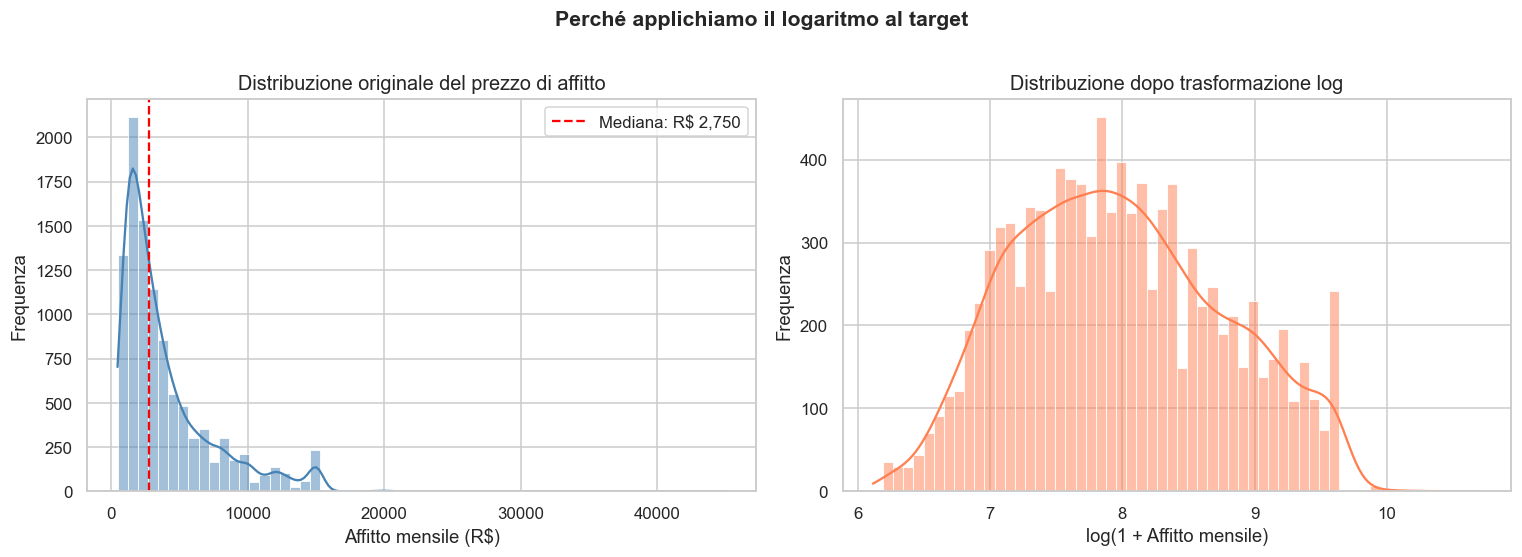


Affitto minimo:  R$        450
Affitto mediano: R$      2,750
Affitto medio:   R$      3,978
Affitto massimo: R$     45,000


In [46]:
# Il nome esatto della colonna target nel dataset Brazilian Houses
TARGET = 'rent_amount_(BRL)'

# Convertiamo subito in float per sicurezza (potrebbe essere caricato come stringa)
df[TARGET] = df[TARGET].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: distribuzione originale
# histplot disegna un istogramma: sull'asse X i valori, sull'asse Y quante volte appaiono.
# kde=True aggiunge la curva di densità (KDE = Kernel Density Estimate),
# che è una versione liscia dell'istogramma e aiuta a vedere la forma della distribuzione.
sns.histplot(df[TARGET], bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuzione originale del prezzo di affitto', fontsize=13)
axes[0].set_xlabel('Affitto mensile (R$)')
axes[0].set_ylabel('Frequenza')

# Aggiungiamo una linea verticale per la mediana
mediana = df[TARGET].median()
axes[0].axvline(mediana, color='red', linestyle='--', label=f'Mediana: R$ {mediana:,.0f}')
axes[0].legend()

# Grafico 2: distribuzione dopo log-transform
# np.log1p(x) calcola log(1 + x). Il +1 evita problemi quando x=0 (log(0) = -∞).
# La trasformazione logaritmica comprime i valori grandi e "appiattisce" la coda destra.
y_log = np.log1p(df[TARGET])
sns.histplot(y_log, bins=60, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribuzione dopo trasformazione log', fontsize=13)
axes[1].set_xlabel('log(1 + Affitto mensile)')
axes[1].set_ylabel('Frequenza')

plt.suptitle('Perché applichiamo il logaritmo al target', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'\nAffitto minimo:  R$ {df[TARGET].min():>10,.0f}')
print(f'Affitto mediano: R$ {df[TARGET].median():>10,.0f}')
print(f'Affitto medio:   R$ {df[TARGET].mean():>10,.0f}')
print(f'Affitto massimo: R$ {df[TARGET].max():>10,.0f}')

> **Perché il logaritmo?**  
> Nel grafico a sinistra vedi una distribuzione con la coda destra molto lunga (**heavy-tail**): la maggior parte degli affitti sta in un range ragionevole, ma alcuni valori estremi tirano la media verso destra.
> 
> Senza logaritmo, il modello ottimizza l'errore in valore assoluto (in reais). Questo significa che sbagliare di R\$5.000 su un affitto da R\$10.000 pesa esattamente quanto sbagliare di R\$5.000 su un affitto da R\$500, il che non ha senso economico.
> 
> Con il logaritmo, ottimizziamo l'errore relativo (in percentuale). Un errore del 10% pesa uguale sia su un affitto economico che su uno di lusso. Più giusto, e anche più facile da imparare per il modello.
> 
> **Dopo il training**, convertiamo le previsioni alla scala originale con `np.expm1(y_log)`, che è l'inverso di `np.log1p`.

### 2.2 Analisi delle feature numeriche

In [47]:
# Identifichiamo le colonne numeriche e categoriche
# select_dtypes filtra le colonne per tipo di dato.
# np.number include sia int64 che float64.
# 'object' e 'category' sono le colonne testuali/categoriche.

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_raw = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Rimuoviamo il target dalla lista delle feature numeriche
feature_num = [c for c in numeric_cols if c != TARGET]

print(f'Feature numeriche ({len(feature_num)}): {feature_num}')
print(f'Feature categoriche ({len(cat_cols_raw)}): {cat_cols_raw}')

Feature numeriche (6): ['area', 'rooms', 'bathroom', 'parking_spaces', 'hoa_(BRL)', 'property_tax_(BRL)']
Feature categoriche (3): ['city', 'animal', 'furniture']


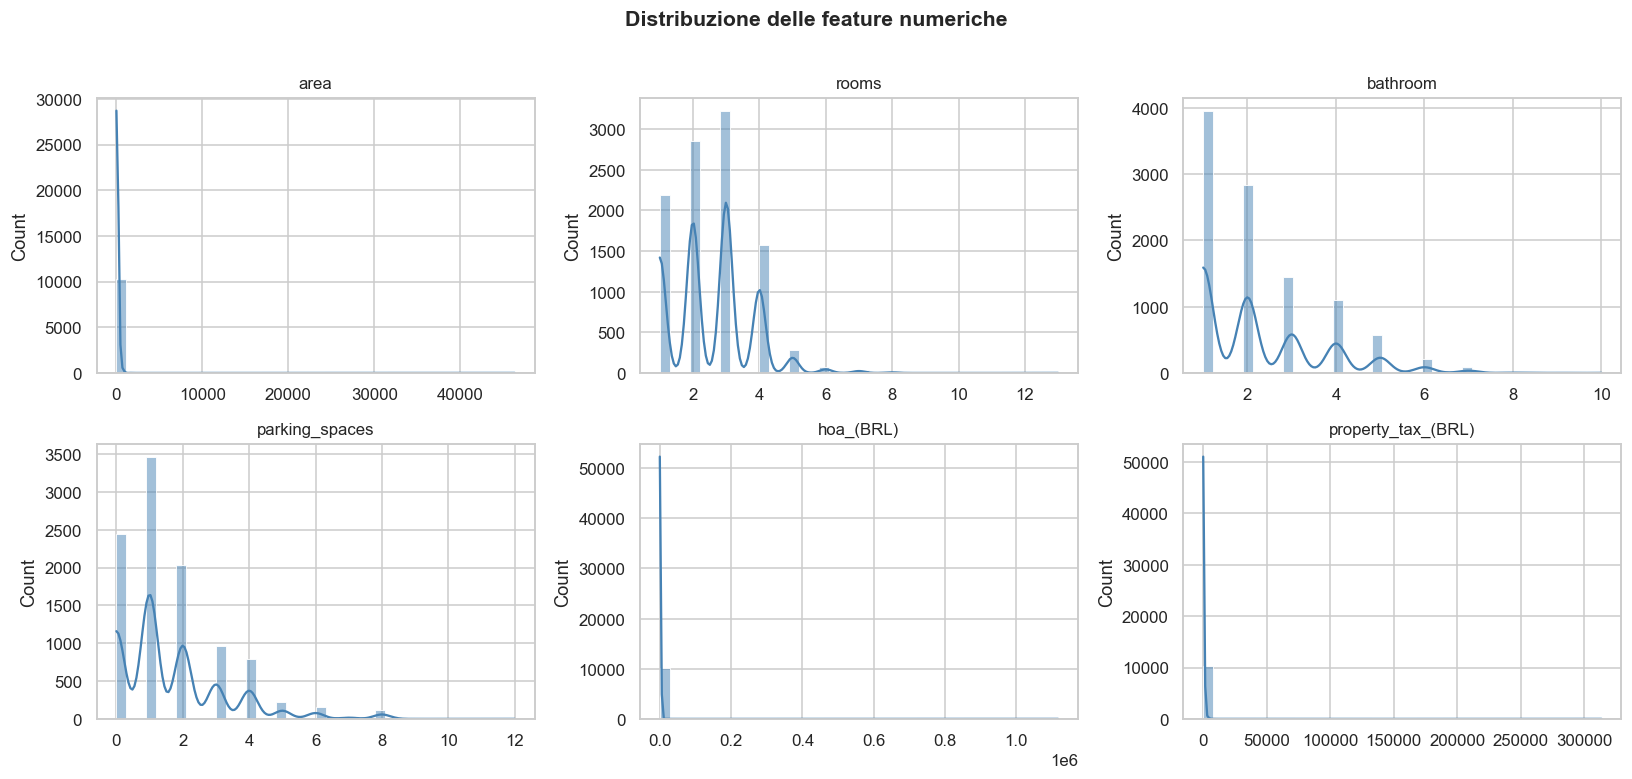

In [48]:
# Istogrammi delle feature numeriche
# Guardiamo la distribuzione di ogni feature numerica.
# Questo ci aiuta a identificare:
#   - distribuzioni asimmetriche (heavy-tail) → potrebbero richiedere log-transform
#   - outlier visibili
#   - feature con range molto diversi → confermano la necessità di scaling

n_cols = 3
n_rows = int(np.ceil(len(feature_num) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()  # convertiamo la griglia 2D in lista 1D per iterare facilmente

for i, col in enumerate(feature_num):
    sns.histplot(df[col].dropna(), bins=40, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

# Nascondiamo gli assi in eccesso se il numero di feature non è multiplo di n_cols
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuzione delle feature numeriche', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Correlazione con il target

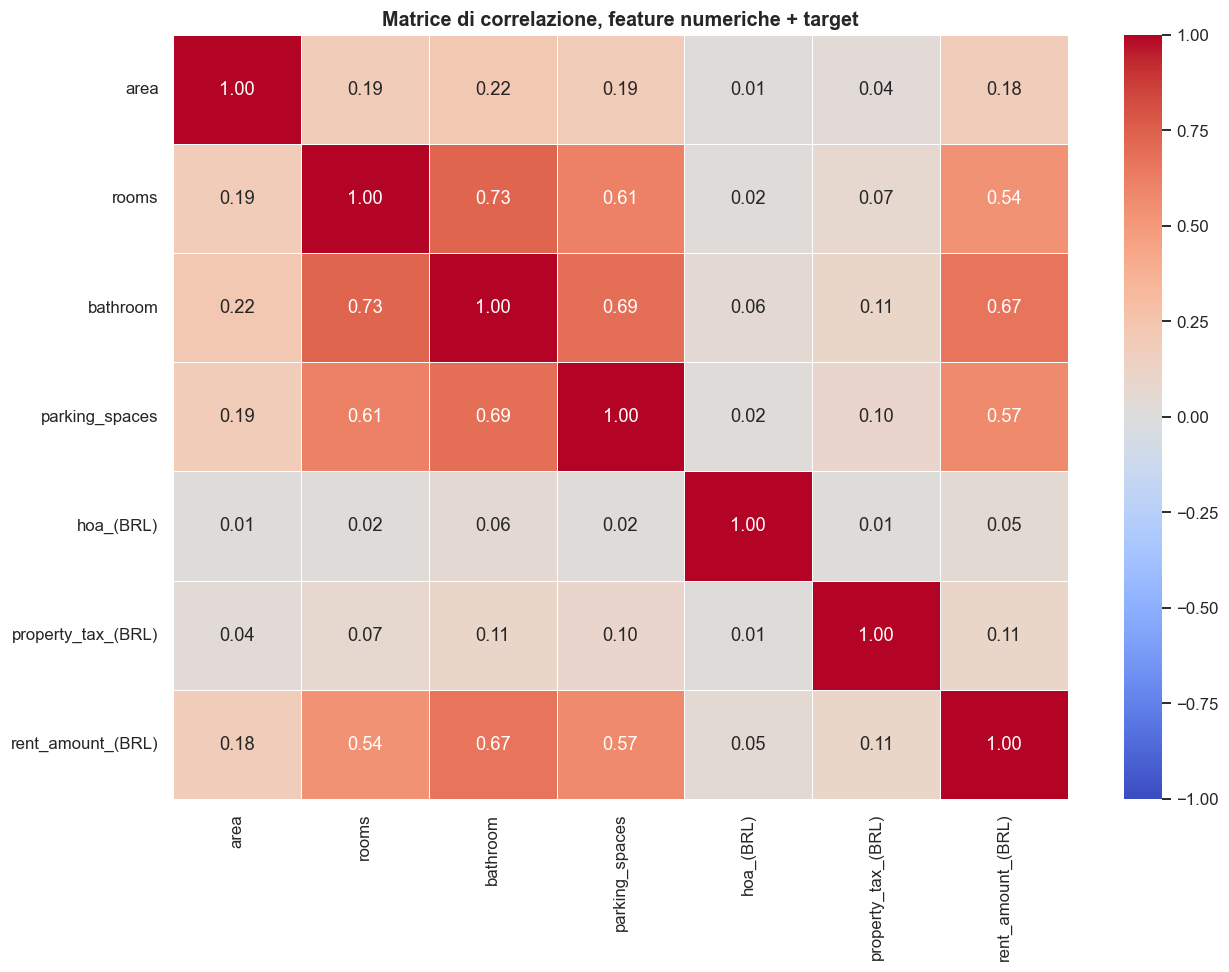

In [49]:
# Heatmap delle correlazioni
# La correlazione misura quanto due variabili si muovono insieme.
#   +1 → correlazione positiva perfetta (una cresce, l'altra cresce)
#    0 → nessuna correlazione lineare
#   -1 → correlazione negativa perfetta (una cresce, l'altra decresce)
#
# .corr() calcola la matrice di correlazione di Pearson tra tutte le colonne numeriche.
# annot=True → scrive il valore numerico dentro ogni cella
# cmap='coolwarm' → rosso = correlazione positiva, blu = negativa
# fmt='.2f' → mostra solo 2 decimali

# Selezioniamo solo le colonne numeriche incluso il target
cols_for_corr = feature_num + [TARGET]
corr_matrix = df[cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1, vmax=1,  # scala fissa tra -1 e 1 per leggibilità
    ax=ax
)
ax.set_title('Matrice di correlazione, feature numeriche + target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [50]:
# Correlazione ordinata con il target
# Estraiamo solo la colonna del target dalla matrice di correlazione,
# prendiamo il valore assoluto (ci interessa la forza, non il segno)
# e ordiniamo dal più correlato al meno.

corr_with_target = (
    corr_matrix[TARGET]
    .drop(TARGET)         # rimuovi la correlazione con se stesso (sempre 1)
    .abs()                # valore assoluto
    .sort_values(ascending=False)
)

print('Correlazione con il target (valore assoluto):')
print(corr_with_target.round(3).to_string())

Correlazione con il target (valore assoluto):
bathroom              0.666
parking_spaces        0.573
rooms                 0.537
area                  0.178
property_tax_(BRL)    0.107
hoa_(BRL)             0.052


### 2.4 Analisi delle feature categoriche

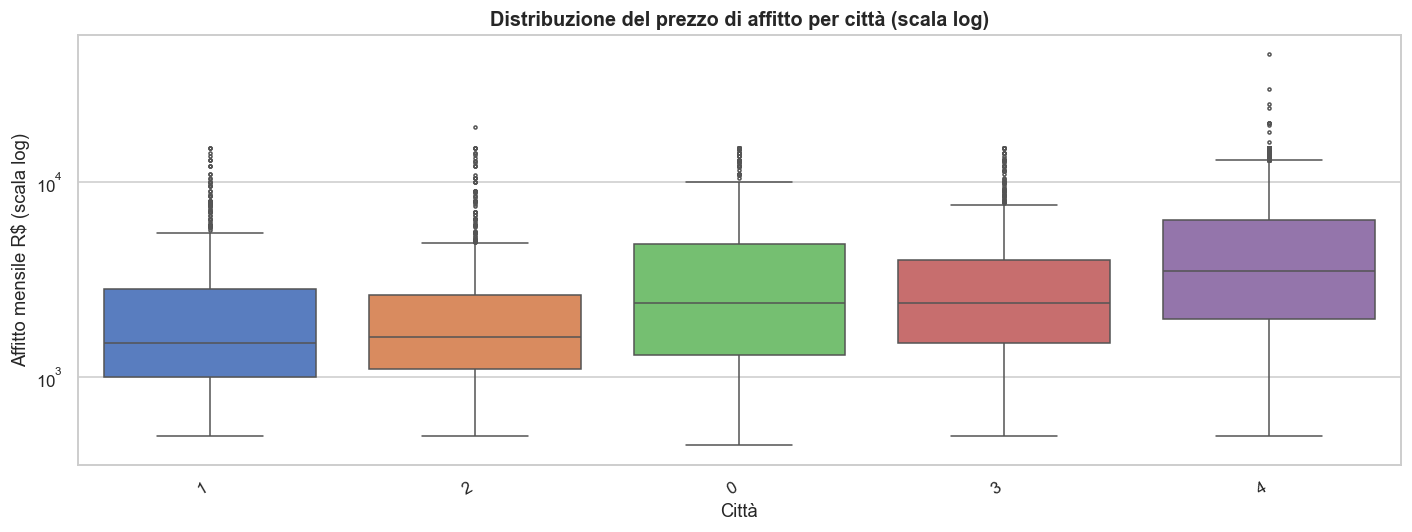

In [51]:
# Boxplot: affitto per città
# Un boxplot mostra per ogni categoria:
#   - la mediana (linea centrale)
#   - il range interquartile IQR (la scatola, dal 25° al 75° percentile)
#   - i valori anomali (punti fuori dai baffi)
# Ci permette di vedere se il prezzo cambia significativamente tra città diverse.

fig, ax = plt.subplots(figsize=(13, 5))
city_col = 'city'  # nome della colonna città nel dataset

# Ordiniamo le città per mediana del prezzo, dal più economico al più caro
city_order = (
    df.groupby(city_col)[TARGET]
    .median()
    .sort_values()
    .index.tolist()
)

sns.boxplot(
    data=df,
    x=city_col,
    y=TARGET,
    order=city_order,
    palette='muted',
    fliersize=2,   # dimensione dei punti outlier
    ax=ax
)
ax.set_yscale('log')  # scala logaritmica sull'asse Y per leggibilità
ax.set_title('Distribuzione del prezzo di affitto per città (scala log)', fontsize=13, fontweight='bold')
ax.set_xlabel('Città')
ax.set_ylabel('Affitto mensile R$ (scala log)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 3. Dividere il dataset

Questo è uno dei passaggi più importanti e deve avvenire **prima** di qualsiasi altra operazione sui dati.

**Perché dividere prima?**  
Il test set simula dati che il modello non ha mai visto. Se lo utilizziamo per prendere decisioni durante lo sviluppo (scegliere feature, calibrare il preprocessing, confrontare modelli), i risultati finali non saranno più una stima onesta delle performance reali, il modello avrà "imparato" indirettamente anche dal test set.

**Regola fondamentale:** il test set si tocca **una sola volta**, alla fine, per la valutazione finale.

In [52]:
# Separare feature e target
# X contiene tutte le colonne tranne il target.
# y contiene solo il target, già trasformato con log1p.

X = df.drop(columns=[TARGET]).copy()
y = np.log1p(df[TARGET].astype(float))   # target in scala logaritmica

# Divisione train/test
# test_size=0.2  → 20% dei dati va nel test set, 80% nel training set
# random_state=42 → garantisce la riproducibilità:
#   ogni volta che esegui questo codice, la divisione è identica.
#   Senza questo parametro, la divisione sarebbe casuale ad ogni esecuzione
#   e non potresti confrontare risultati tra run diverse.
#   Il numero 42 non ha nulla di speciale, è solo una convenzione.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Training set: {X_train.shape[0]:>5} righe  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:     {X_test.shape[0]:>5} righe  ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nFeature totali: {X_train.shape[1]}')

Training set:  8196 righe  (80%)
Test set:      2050 righe  (20%)

Feature totali: 9


---
## 4. Feature Engineering

Il Feature Engineering è il processo di creare nuove feature a partire da quelle esistenti, con l'obiettivo di rendere i pattern più facili da catturare per il modello.

**Principio chiave:** un modello semplice con feature ben costruite batte quasi sempre un modello sofisticato con feature grezze. La qualità delle feature è spesso più importante della scelta del modello.

Per il Brazilian Houses creiamo alcune feature che hanno senso economico:
- **`total_cost`**: somma di affitto + altre spese, ma attenzione, questo è il target implicito, quindi usiamo solo le componenti non legate all'affitto
- **`rooms_per_bathroom`**: efficienza dell'appartamento
- **`area_per_room`**: spazio medio per stanza
- **`has_parking`**: variabile binaria (0/1) dal numero di parcheggi

In [53]:
def add_features(X):
    
    #Aggiunge feature ingegnerizzate al DataFrame.
    
    #Riceve X in input e restituisce una copia con le nuove colonne.
    #Lavoriamo sempre su .copy() per evitare di modificare il DataFrame originale
    #(un errore comune che porta a bug difficili da tracciare).

    X = X.copy()
    
    # Convertiamo le colonne a float prima di fare operazioni:
    # i dati da OpenML a volte arrivano come object anche se sono numerici.
    # fillna(0) sostituisce i NaN con 0 prima di calcolare: senza questo,
    # qualsiasi operazione su un NaN restituisce NaN.
    
    area = X['area'].astype(float).fillna(0)
    rooms = X['rooms'].astype(float).fillna(1)      # fillna(1) per evitare divisione per 0
    bathrooms = X['bathroom'].astype(float).fillna(1)
    parking = X['parking_spaces'].astype(float).fillna(0)
    
    # Spazio medio per stanza (mq per stanza)
    X['area_per_room'] = area / rooms
    
    # Rapporto stanze/bagni: un valore basso indica molti bagni relativo alle stanze
    X['rooms_per_bathroom'] = rooms / bathrooms
    
    # Variabile binaria: ha almeno un posto auto?
    # (parking > 0) restituisce True/False, .astype(int) lo converte in 1/0
    X['has_parking'] = (parking > 0).astype(int)
    
    # Dimensione dell'appartamento in categorie ordinate
    # pd.cut divide un range numerico in intervalli (bins) e assegna un'etichetta a ciascuno
    X['size_category'] = pd.cut(
        area,
        bins=[0, 40, 80, 150, float('inf')],
        labels=['micro', 'small', 'medium', 'large'],
        right=True     # gli intervalli sono chiusi a destra: (0, 40]
    ).astype(str)      # convertiamo a stringa per il OneHotEncoder
    
    return X


# Applichiamo SEPARATAMENTE a training e test set.
# MAI applicare su tutto il dataset insieme prima di fare lo split:
# anche qui potremmo introdurre data leakage se usassimo statistiche globali.
X_train = add_features(X_train)
X_test  = add_features(X_test)

print('Feature dopo feature engineering:')
print(X_train.columns.tolist())

Feature dopo feature engineering:
['city', 'area', 'rooms', 'bathroom', 'parking_spaces', 'animal', 'furniture', 'hoa_(BRL)', 'property_tax_(BRL)', 'area_per_room', 'rooms_per_bathroom', 'has_parking', 'size_category']


---
## 5. Costruire la Pipeline di Preprocessing

A questo punto dobbiamo:
1. Gestire i valori mancanti (imputation)
2. Convertire le variabili categoriche in numeri (encoding)
3. Portare tutte le feature sulla stessa scala (scaling)

Se applicassimo questi step manualmente uno alla volta ogni volta che vogliamo fare una previsione, sarebbe:
- Noioso e soggetto a errori
- Facile dimenticarsi un passaggio
- Impossibile da mantenere quando il codice cresce

La soluzione è la **Pipeline di scikit-learn**: una sequenza ordinata di trasformazioni gestita come un unico oggetto.

> ⚠️ **Data Leakage**, il pericolo più insidioso  
> Tutte le statistiche usate nel preprocessing (media, mediana, deviazione standard) devono essere calcolate **solo** sul training set, e poi applicate al test set.  
> Se le calcoliamo sull'intero dataset prima dello split, il modello "vede" informazioni dal test set durante il training, e le sue performance appariranno migliori di quelle reali. La pipeline gestisce questo automaticamente con `.fit()` e `.transform()` separati.

In [54]:
# 1. Identifichiamo AUTOMATICAMENTE le numeriche e le categoriche
# Seleziona tutto ciò che è numero (int, float)
all_numeric = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Seleziona tutto ciò che è testo o categoria
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Gestiamo la distinzione per la Log-Transform (Asimmetria)
# Invece di scrivere i nomi, usiamo la statistica: 
# se la skewness (asimmetria) è alta (> 1), va in log_cols
log_cols = [col for col in all_numeric if X_train[col].skew() > 1]

# 3. Le numeriche normali sono quelle che restano
num_cols = [col for col in all_numeric if col not in log_cols]

print(f"Log Columns (Asimmetriche): {log_cols}")
print(f"Num Columns (Normali):      {num_cols}")
print(f"Cat Columns (Testuali):     {cat_cols}")

Log Columns (Asimmetriche): ['area', 'bathroom', 'parking_spaces', 'hoa_(BRL)', 'property_tax_(BRL)', 'area_per_room', 'rooms_per_bathroom']
Num Columns (Normali):      ['rooms', 'has_parking']
Cat Columns (Testuali):     ['city', 'animal', 'furniture', 'size_category']


In [55]:
# Costruire i transformer per ogni tipo di colonna

# 1. Transformer per colonne con distribuzione asimmetrica
# make_pipeline crea una pipeline senza dover assegnare nomi agli step:
# scikit-learn li nomina automaticamente (simpleimputer, functiontransformer, ...).

log_transformer = make_pipeline(
    # Step 1: sostituisce i NaN con la mediana della colonna
    # strategy='median' è preferibile a 'mean' in presenza di outlier:
    # la mediana non è influenzata dai valori estremi.
    SimpleImputer(strategy='median'),
    
    # Step 2: applica log(1+x) per "schiacciare" la coda destra
    # validate=True controlla che l'input sia valido (no NaN, array 2D)
    # feature_names_out='one-to-one' dice che l'output ha gli stessi nomi dell'input
    FunctionTransformer(np.log1p, validate=True, feature_names_out='one-to-one'),
    
    # Step 3: standardizza → media 0, deviazione standard 1
    StandardScaler()
)

# 2. Transformer per colonne numeriche normali
num_transformer = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

# 3. Transformer per colonne categoriche
cat_transformer = make_pipeline(
    # Per le categoriche usiamo la moda (valore più frequente) per i NaN
    SimpleImputer(strategy='most_frequent'),
    
    # OneHotEncoder crea una colonna binaria (0/1) per ogni categoria.
    # handle_unknown='ignore' → se nel test set appare una categoria mai vista
    # nel training, la ignora (mette tutti 0) invece di alzare un errore.
    # sparse_output=False → restituisce un array denso invece di una matrice sparsa,
    # più semplice da gestire con pandas.
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

# ColumnTransformer: orchestra i tre transformer
# Ogni tupla è: ('nome', transformer, colonne_su_cui_applicarlo)
# Il ColumnTransformer applica ogni transformer alle sue colonne in parallelo
# e poi concatena i risultati in un unico array.

preprocessor = ColumnTransformer(
    transformers=[
        ('log', log_transformer, log_cols),
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols),
    ],
    remainder='drop'   # droppa le colonne non specificate
)

print('Preprocessor costruito.')
print('\nSchema del ColumnTransformer:')
print(f'  log_transformer  → {log_cols}')
print(f'  num_transformer  → {num_cols}')
print(f'  cat_transformer  → {cat_cols}')

Preprocessor costruito.

Schema del ColumnTransformer:
  log_transformer  → ['area', 'bathroom', 'parking_spaces', 'hoa_(BRL)', 'property_tax_(BRL)', 'area_per_room', 'rooms_per_bathroom']
  num_transformer  → ['rooms', 'has_parking']
  cat_transformer  → ['city', 'animal', 'furniture', 'size_category']


---
## 6. Addestrare il modello, Baseline

Prima di provare modelli complessi, partiamo sempre da un **modello baseline**: il modello più semplice possibile che ha senso per il problema.

Serve come punto di riferimento: se il modello sofisticato non batte la baseline, stai perdendo tempo.

Per la regressione, una buona baseline è la **Linear Regression**: assume una relazione lineare tra le feature e il target. È veloce, interpretabile, e spesso sorprendentemente competitiva.

In [56]:
# Pipeline completa: preprocessing + modello 
# Mettiamo il preprocessor e il modello in un'unica Pipeline.
# Vantaggi:
#   1. Un solo .fit() fa tutto: preprocessing + training
#   2. Un solo .predict() fa tutto: preprocessing dei nuovi dati + previsione
#   3. Non puoi dimenticare nessuno step perché sono tutti dentro la pipeline
#   4. Nessun rischio di data leakage: fit() del preprocessor usa solo X_train

lin_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

# .fit() su X_train:
#   1. Calcola mediana e std di ogni colonna numerica (solo su X_train)
#   2. Impara le categorie per il OneHotEncoder (solo da X_train)
#   3. Addestra la regressione lineare sui dati preprocessati
lin_pipeline.fit(X_train, y_train)

# Previsioni sul training set (solo per un controllo rapido)
train_preds = lin_pipeline.predict(X_train)
train_rmse  = root_mean_squared_error(y_train, train_preds)
train_mae   = mean_absolute_error(y_train, train_preds)

print(' Baseline: Linear Regression ')
print(f'Training RMSE (scala log): {train_rmse:.4f}')
print(f'Training MAE  (scala log): {train_mae:.4f}')
print()
print('NB: un errore molto basso sul training non è necessariamente buono:')
print('    potrebbe indicare overfitting. Valuteremo con la cross-validation.')

 Baseline: Linear Regression 
Training RMSE (scala log): 0.4386
Training MAE  (scala log): 0.3449

NB: un errore molto basso sul training non è necessariamente buono:
    potrebbe indicare overfitting. Valuteremo con la cross-validation.


---
## 7. Cross-validation

Controllare solo l'errore sul training set non basta, anzi, può essere fuorviante.

Un modello che va benissimo sul training ma male su dati nuovi è in **overfitting**: ha memorizzato i dati invece di imparare i pattern sottostanti.

La **cross-validation** risolve questo problema valutando il modello su più validation set diversi:

```
Dataset di training diviso in 5 fold:

Fold 1: [VAL] [TRN] [TRN] [TRN] [TRN]  → misura errore sul fold 1
Fold 2: [TRN] [VAL] [TRN] [TRN] [TRN]  → misura errore sul fold 2
Fold 3: [TRN] [TRN] [VAL] [TRN] [TRN]  → misura errore sul fold 3
Fold 4: [TRN] [TRN] [TRN] [VAL] [TRN]  → misura errore sul fold 4
Fold 5: [TRN] [TRN] [TRN] [TRN] [VAL]  → misura errore sul fold 5

Risultato finale = media dei 5 errori
```

La media è una stima molto più affidabile rispetto a una singola divisione train/test.

In [57]:
def run_cv(pipeline, X, y, cv=5, nome='Modello'):
    """
    Esegue la cross-validation e stampa le statistiche.
    
    cross_val_score con scoring='neg_root_mean_squared_error':
    scikit-learn usa la convenzione "più alto è meglio" per tutti gli score.
    Ma per l'errore vale il contrario (vogliamo un errore basso).
    Quindi restituisce il NEGATIVO dell'RMSE → lo riportiamo positivo con il -.
    """
    rmses = -cross_val_score(
        pipeline, X, y,
        scoring='neg_root_mean_squared_error',
        cv=cv,
        n_jobs=-1   # usa tutti i core disponibili per velocizzare
    )
    
    stats = pd.Series(rmses).describe()
    
    print(f' {nome}, Cross-Validation (cv={cv}) ')
    print(f'  Media RMSE:   {stats["mean"]:.4f}  ← la stima più affidabile')
    print(f'  Std RMSE:     {stats["std"]:.4f}  ← variabilità tra i fold')
    print(f'  Min RMSE:     {stats["min"]:.4f}  ← fold migliore')
    print(f'  Max RMSE:     {stats["max"]:.4f}  ← fold peggiore')
    print(f'  RMSE per fold: {[f"{r:.4f}" for r in rmses]}')
    print()
    
    return rmses


# Baseline: Linear Regression
lin_rmses = run_cv(lin_pipeline, X_train, y_train, nome='Linear Regression')

# Modello più potente: Random Forest
# Un Random Forest addestra centinaia di alberi decisionali su sottoinsiemi
# diversi dei dati (bagging) e ne fa la media.
# n_estimators=100 → 100 alberi (default, buon punto di partenza)
# n_jobs=-1        → addestra gli alberi in parallelo su tutti i core
rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_rmses = run_cv(rf_pipeline, X_train, y_train, nome='Random Forest')

 Linear Regression, Cross-Validation (cv=5) 
  Media RMSE:   0.4396  ← la stima più affidabile
  Std RMSE:     0.0098  ← variabilità tra i fold
  Min RMSE:     0.4271  ← fold migliore
  Max RMSE:     0.4529  ← fold peggiore
  RMSE per fold: ['0.4385', '0.4271', '0.4350', '0.4529', '0.4446']

 Random Forest, Cross-Validation (cv=5) 
  Media RMSE:   0.4084  ← la stima più affidabile
  Std RMSE:     0.0097  ← variabilità tra i fold
  Min RMSE:     0.3976  ← fold migliore
  Max RMSE:     0.4242  ← fold peggiore
  RMSE per fold: ['0.4067', '0.3976', '0.4080', '0.4242', '0.4058']



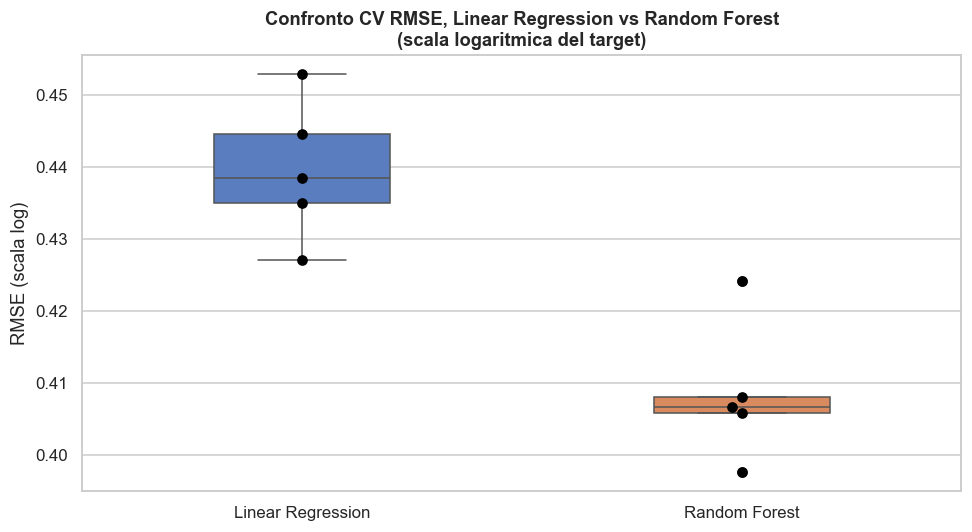

Confronto media CV RMSE (più basso = meglio):
  Linear Regression: 0.4396
  Random Forest:     0.4084
  → Random Forest migliora del 7.1%


In [58]:
# Visualizzazione: confronto tra modelli 
# Un boxplot dei CV scores ci mostra non solo la performance media
# ma anche la stabilità: un box stretto indica un modello consistente.

fig, ax = plt.subplots(figsize=(9, 5))

data_plot = pd.DataFrame({
    'Linear Regression': lin_rmses,
    'Random Forest':     rf_rmses,
})

# Boxplot + swarmplot: il boxplot mostra la distribuzione,
# lo swarmplot mostra i singoli punti (uno per fold)
data_melt = data_plot.melt(var_name='Modello', value_name='CV RMSE')
sns.boxplot(data=data_melt, x='Modello', y='CV RMSE', palette='muted', ax=ax, width=0.4)
sns.swarmplot(data=data_melt, x='Modello', y='CV RMSE', color='black', size=7, ax=ax)

ax.set_title('Confronto CV RMSE, Linear Regression vs Random Forest\n(scala logaritmica del target)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (scala log)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

# Confronto numerico
print('Confronto media CV RMSE (più basso = meglio):')
print(f'  Linear Regression: {lin_rmses.mean():.4f}')
print(f'  Random Forest:     {rf_rmses.mean():.4f}')
miglioramento = (lin_rmses.mean() - rf_rmses.mean()) / lin_rmses.mean() * 100
print(f'  → Random Forest migliora del {miglioramento:.1f}%')

---
## 8. Hyperparameter Tuning

**Parametri vs Iperparametri**, distinzione fondamentale:
- **Parametri**: vengono appresi automaticamente durante il training (es. i pesi di una regressione lineare)
- **Iperparametri**: li imposti tu *prima* del training e controllano *come* il modello impara

Per un Random Forest, gli iperparametri principali sono:
- `n_estimators`: quanti alberi addestrare (più alberi = più stabile, ma più lento)
- `max_depth`: profondità massima di ogni albero (limita l'overfitting)
- `max_features`: quante feature considera ogni split (introduce diversità tra gli alberi)
- `min_samples_leaf`: numero minimo di esempi in ogni foglia (regolarizzazione)

Trovare la combinazione migliore si chiama **hyperparameter tuning**.

**Perché `RandomizedSearchCV` invece di `GridSearchCV`?**  
La Grid Search prova *tutte* le combinazioni: con 4 iperparametri e 5 valori ciascuno, sono 5⁴ = 625 combinazioni. Troppo lento.  
`RandomizedSearchCV` campiona casualmente `n_iter` combinazioni dallo spazio degli iperparametri, trovando risultati comparabili in una frazione del tempo.

In [59]:
# Definire lo spazio degli iperparametri 
# randint(low, high) campiona interi uniformemente nell'intervallo [low, high).
# Il prefisso 'model__' dice a scikit-learn che questo iperparametro
# appartiene allo step 'model' della pipeline (non al preprocessor).
# NB: Questa cella può richiedere qualche minuto per runnare

param_distribs = {
    'model__n_estimators':     randint(50, 400),    # numero di alberi
    'model__max_depth':        randint(5, 30),       # profondità massima
    'model__max_features':     randint(3, 20),       # feature per ogni split
    'model__min_samples_leaf': randint(1, 15),       # min esempi in ogni foglia
}

#  RandomizedSearchCV 
rnd_search = RandomizedSearchCV(
    rf_pipeline,                            # pipeline da ottimizzare
    param_distributions=param_distribs,
    n_iter=30,                              # quante combinazioni provare
    cv=3,                                   # cross-validation a 3 fold (più veloce)
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,                              # parallelizza
    verbose=1                               # stampa il progresso
)

# .fit() qui fa:
#   1. Campiona 30 combinazioni di iperparametri
#   2. Per ognuna, esegue una CV a 3 fold
#   3. Tiene traccia della combinazione migliore
rnd_search.fit(X_train, y_train)

print('\nRicerca completata.')
print(f'Migliori iperparametri trovati:')
for k, v in rnd_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMiglior CV RMSE: {-rnd_search.best_score_:.4f}')

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Ricerca completata.
Migliori iperparametri trovati:
  model__max_depth: 29
  model__max_features: 5
  model__min_samples_leaf: 5
  model__n_estimators: 356

Miglior CV RMSE: 0.4004


In [60]:
# Analisi dei risultati della ricerca 
# cv_results_ è un dizionario con tutti i risultati.
# Lo convertiamo in DataFrame per analizzarlo facilmente.

results_df = pd.DataFrame(rnd_search.cv_results_)

# Selezioniamo solo le colonne che ci interessano
cols_to_show = [
    'param_model__n_estimators',
    'param_model__max_depth',
    'param_model__max_features',
    'param_model__min_samples_leaf',
    'mean_test_score',
    'std_test_score'
]

results_clean = results_df[cols_to_show].copy()
# I test_score sono negativi (convenzione scikit-learn), li riportiamo positivi
results_clean['CV_RMSE'] = -results_clean['mean_test_score']
results_clean['CV_std']  = results_clean['std_test_score']
results_clean = results_clean.drop(columns=['mean_test_score', 'std_test_score'])
results_clean = results_clean.sort_values('CV_RMSE').reset_index(drop=True)

print('Top 5 combinazioni trovate (ordinate per RMSE crescente):')
print(results_clean.head(5).to_string(index=False))

Top 5 combinazioni trovate (ordinate per RMSE crescente):
 param_model__n_estimators  param_model__max_depth  param_model__max_features  param_model__min_samples_leaf  CV_RMSE   CV_std
                       356                      29                          5                              5 0.400441 0.003460
                       141                      25                          4                              4 0.400925 0.002873
                       358                      12                          5                              6 0.401468 0.003616
                       257                      29                         10                              5 0.401499 0.003269
                       359                      10                         12                              4 0.401923 0.003548


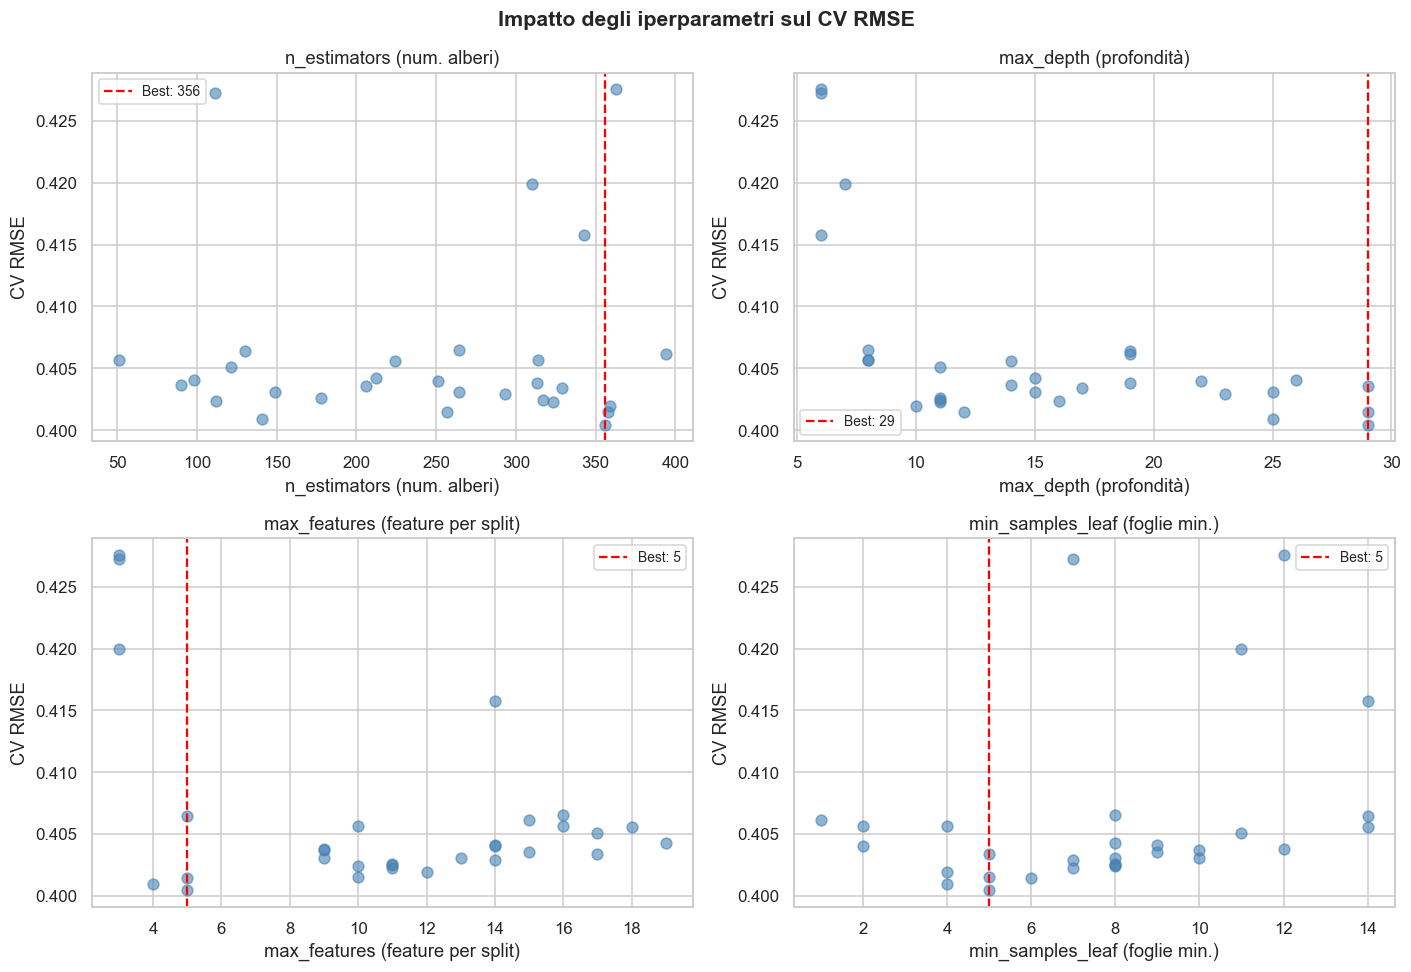

In [61]:
# Visualizzazione: importanza degli iperparametri 
# Scatter plot: ogni punto è una combinazione provata.
# Sull'asse X l'iperparametro, sull'asse Y l'RMSE.
# Ci dice se quell'iperparametro ha un impatto grande o piccolo.

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

param_labels = {
    'param_model__n_estimators':     'n_estimators (num. alberi)',
    'param_model__max_depth':        'max_depth (profondità)',
    'param_model__max_features':     'max_features (feature per split)',
    'param_model__min_samples_leaf': 'min_samples_leaf (foglie min.)'
}

for i, (param, label) in enumerate(param_labels.items()):
    x = results_clean[param].astype(float)
    y_rmse = results_clean['CV_RMSE']
    
    axes[i].scatter(x, y_rmse, alpha=0.6, s=50, color='steelblue')
    # Evidenziamo il valore migliore in rosso
    best_val = rnd_search.best_params_[param.replace('param_', '')]
    axes[i].axvline(best_val, color='red', linestyle='--', linewidth=1.5, 
                    label=f'Best: {best_val}')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('CV RMSE')
    axes[i].set_title(label)
    axes[i].legend(fontsize=9)

plt.suptitle('Impatto degli iperparametri sul CV RMSE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

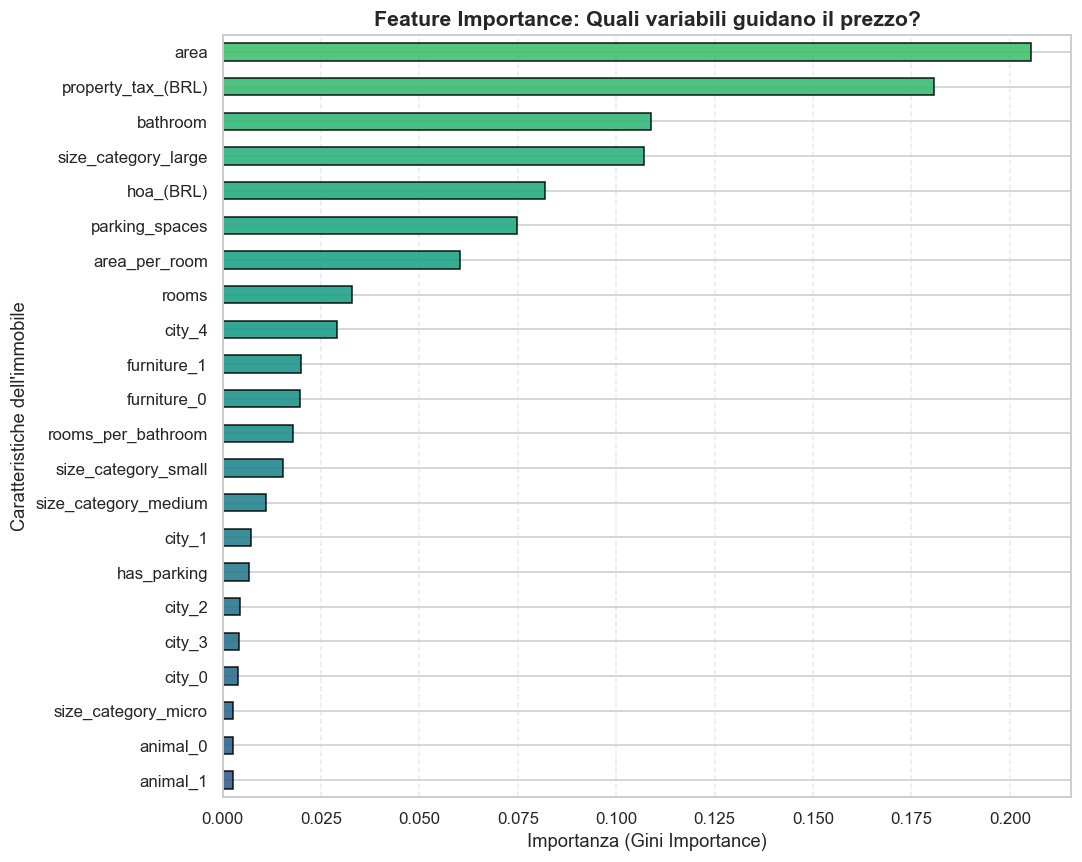


TOP 10 FEATURE PIÙ DETERMINANTI


,Importanza
area,0.205392
property_tax_(BRL),0.180854
bathroom,0.108954
size_category_large,0.107098
hoa_(BRL),0.081876
parking_spaces,0.074942
area_per_room,0.060432
rooms,0.033020
city_4,0.029078
furniture_1,0.020059


In [62]:
# Visualizzazione: importanza delle feature per Random Forest
# 1. Recuperiamo il modello migliore e il preprocessor
best_pipeline = rnd_search.best_estimator_
model = best_pipeline.named_steps['model']
preprocessor = best_pipeline.named_steps['preprocessing']

# 2. Recuperiamo i nomi delle feature in modo robusto
# Dobbiamo iterare sui transformer del ColumnTransformer per avere i nomi corretti
feature_names = []

# Feature dai transformer 'log' e 'num' (nomi originali)
feature_names.extend(log_cols)
feature_names.extend(num_cols)

# Feature dal transformer 'cat' (nomi generati dal OneHotEncoder)
cat_pipeline = preprocessor.named_transformers_['cat']
ohe_feature_names = cat_pipeline.named_steps['onehotencoder'].get_feature_names_out(cat_cols)
feature_names.extend(ohe_feature_names)

# 3. Creiamo il DataFrame delle importanze
importances = pd.Series(model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=True)

# 4. Visualizzazione professionale
plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0.3, 0.7, len(importances)))
importances.plot(kind='barh', color=colors, edgecolor='black', alpha=0.9)

plt.title('Feature Importance: Quali variabili guidano il prezzo?', fontsize=14, fontweight='bold')
plt.xlabel('Importanza (Gini Importance)', fontsize=12)
plt.ylabel('Caratteristiche dell\'immobile', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 5. Tabella riassuntiva per il libro
print("\nTOP 10 FEATURE PIÙ DETERMINANTI")
display(importances.sort_values(ascending=False).head(10).to_frame(name='Importanza'))

### Perché l'importanza differisce dalla correlazione?

Se confrontiamo questa classifica con la matrice di correlazione iniziale, notiamo delle differenze interessanti (ad esempio, l'importanza elevata di `property_tax_(BRL)` e `size_category_large`). Questo accade per tre motivi principali:

1. **Non-linearità**: La correlazione di Pearson misura solo relazioni lineari (linee rette). Il Random Forest cattura relazioni non lineari e soglie critiche che la correlazione semplice non vede.
2. **Interazioni**: L'importanza del modello valuta quanto una feature sia utile *in combinazione con le altre*. Ad esempio, le tasse di proprietà possono essere un forte indicatore del pregio della zona, fornendo informazioni che l'area da sola non dà.
3. **Feature Engineering**: Vedere le feature create da noi (come `size_category`) nelle prime posizioni conferma che la nostra manipolazione dei dati ha aiutato il modello a semplificare i pattern complessi. Questo ti può far capire, quanto la parte di feature engineering sia importante...

In sintesi: la correlazione ci dà un'idea iniziale, ma l'importanza del modello ci dice cosa conta davvero per la previsione finale

---
## 9. Valutazione finale sul test set

Siamo arrivati all'ultimo step. Usiamo il test set **per la prima e unica volta**.

Il `best_estimator_` è già la pipeline completa configurata con i migliori iperparametri trovati. Non dobbiamo riaddestrare nulla: `RandomizedSearchCV` ha già rifittato il modello su tutto il training set con i migliori parametri.

In [63]:
# Il modello finale è già pronto, è il miglior modello trovato dalla ricerca,
# già riaddesstrato su tutto X_train con i migliori iperparametri.
final_model = rnd_search.best_estimator_

#  Previsioni sul test set 
# La pipeline applica automaticamente il preprocessing prima di fare la previsione.
# Le previsioni sono in scala logaritmica (come y_test).
final_preds_log = final_model.predict(X_test)

#  RMSE in scala logaritmica 
final_rmse_log = root_mean_squared_error(y_test, final_preds_log)
final_mae_log  = mean_absolute_error(y_test, final_preds_log)

#  Conversione alla scala originale (R$) 
# np.expm1(x) = e^x - 1, l'inverso di np.log1p(x) = log(1+x)
final_preds_brl = np.expm1(final_preds_log)
y_test_brl      = np.expm1(y_test)

final_rmse_brl = root_mean_squared_error(y_test_brl, final_preds_brl)
final_mae_brl  = mean_absolute_error(y_test_brl, final_preds_brl)

print(f'  RMSE (scala log):       {final_rmse_log:.4f}')
print(f'  MAE  (scala log):       {final_mae_log:.4f}')
print()
print(f'  RMSE (scala originale): R$ {final_rmse_brl:>10,.0f}')
print(f'  MAE  (scala originale): R$ {final_mae_brl:>10,.0f}')
print()
print('  → Questo è il generalization error: la stima più onesta di')
print('    come il modello si comporterà su dati che non ha mai visto.')

  RMSE (scala log):       0.3831
  MAE  (scala log):       0.2998

  RMSE (scala originale): R$      2,135
  MAE  (scala originale): R$      1,293

  → Questo è il generalization error: la stima più onesta di
    come il modello si comporterà su dati che non ha mai visto.


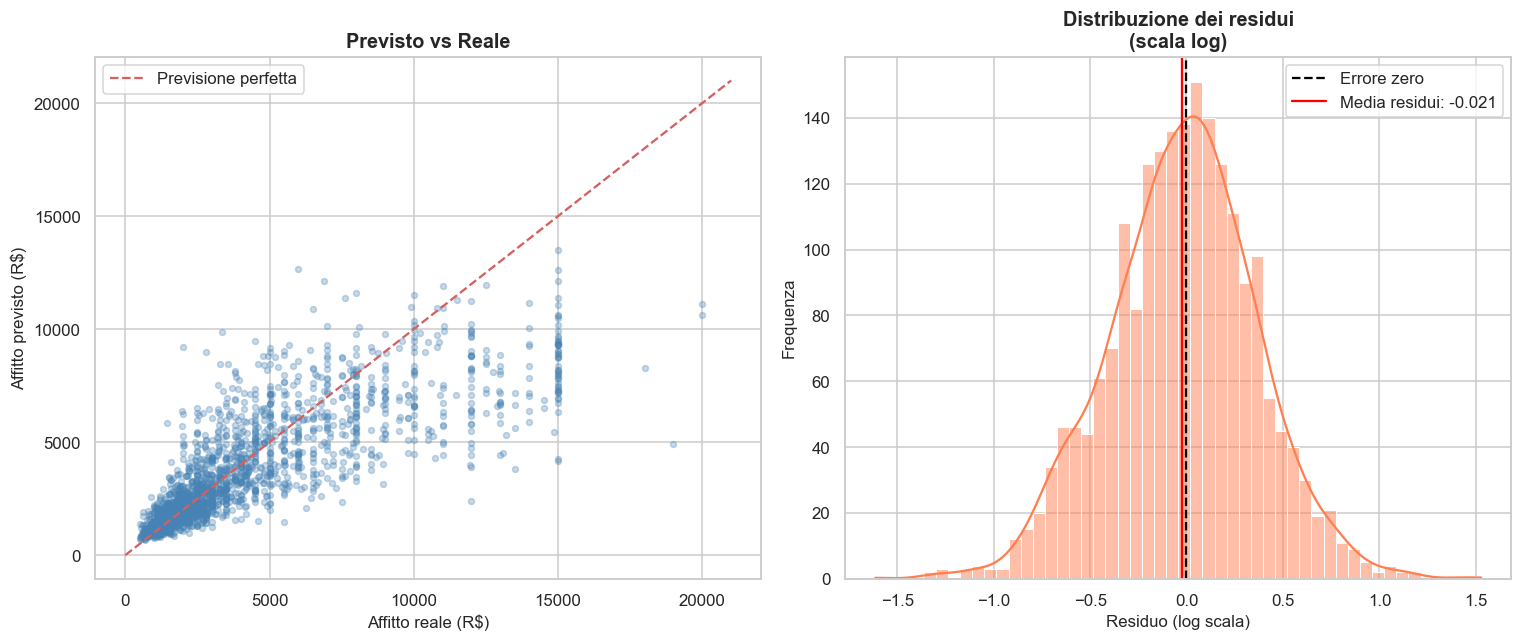

In [64]:
# Grafico: previsioni vs valori reali 
# In un modello perfetto, tutti i punti starebbero sulla diagonale.
# Quanto più i punti si disperdono attorno alla diagonale, tanto meno
# accurato è il modello.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#  Grafico 1: Previsto vs Reale 
ax = axes[0]
ax.scatter(y_test_brl, final_preds_brl, alpha=0.3, s=15, color='steelblue')

# Linea diagonale = previsione perfetta
lim_max = max(y_test_brl.max(), final_preds_brl.max()) * 1.05
ax.plot([0, lim_max], [0, lim_max], 'r--', linewidth=1.5, label='Previsione perfetta')

ax.set_xlabel('Affitto reale (R$)', fontsize=11)
ax.set_ylabel('Affitto previsto (R$)', fontsize=11)
ax.set_title('Previsto vs Reale', fontsize=13, fontweight='bold')
ax.legend()

# Grafico 2: distribuzione dei residui 
# I residui sono la differenza tra previsto e reale.
# In un buon modello i residui dovrebbero essere:
#   - centrati attorno a 0 (il modello non è sistematicamente troppo alto o troppo basso)
#   - distribuiti in modo approssimativamente simmetrico
residuals = final_preds_log - y_test  # in scala log
ax2 = axes[1]
sns.histplot(residuals, bins=50, kde=True, ax=ax2, color='coral')
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Errore zero')
ax2.axvline(residuals.mean(), color='red', linestyle='-', linewidth=1.5,
            label=f'Media residui: {residuals.mean():.3f}')
ax2.set_xlabel('Residuo (log scala)', fontsize=11)
ax2.set_ylabel('Frequenza', fontsize=11)
ax2.set_title('Distribuzione dei residui\n(scala log)', fontsize=13, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

In [65]:
# Tabella: esempi di previsioni 
# Guardiamo alcune previsioni concrete: quale era il prezzo reale,
# cosa ha previsto il modello e quanto si è sbagliato.

n_samples = 10
sample_idx = np.random.choice(len(X_test), n_samples, replace=False)

sample_real = y_test_brl.iloc[sample_idx].values
sample_pred = final_preds_brl[sample_idx]
sample_err  = sample_pred - sample_real
sample_err_pct = (sample_err / sample_real) * 100

preview = pd.DataFrame({
    'Reale (R$)':      sample_real.round(0).astype(int),
    'Previsto (R$)':   sample_pred.round(0).astype(int),
    'Errore (R$)':     sample_err.round(0).astype(int),
    'Errore (%)':      sample_err_pct.round(1)
})

print('Esempi di previsioni sul test set:')
print(preview.to_string(index=False))

Esempi di previsioni sul test set:
 Reale (R$)  Previsto (R$)  Errore (R$)  Errore (%)
       1700           1834          134         7.9
       5650           3180        -2470       -43.7
       1400           2205          805        57.5
       4350           4898          548        12.6
       1900           2252          352        18.5
       1900           2513          613        32.3
      13000           7999        -5001       -38.5
       1200           1137          -63        -5.2
      15000           9042        -5958       -39.7
       2500           3542         1042        41.7


---
## 10. Salvare e ricaricare il modello

Addestrare un modello richiede tempo e risorse. Una volta ottenuto il modello finale, lo salviamo su disco con `joblib` in modo da poterlo riutilizzare senza dover ripetere tutto il processo.

Poiché il preprocessing è **dentro la pipeline**, non dobbiamo preoccuparci di riapplicarlo manualmente: basterà caricare il file `.pkl` e chiamare `.predict()` su dati grezzi.

In [66]:
MODEL_PATH = 'brazilian_houses_model.pkl'

#  Salvare 
# joblib.dump serializza l'intero oggetto Python (pipeline + modello + 
# tutti i parametri appresi) in un file binario.
joblib.dump(final_model, MODEL_PATH)
print(f'Modello salvato in: {MODEL_PATH}')

#  Ricaricare 
# joblib.load ricostruisce l'oggetto dal file.
# Dopo questa riga, reloaded_model è identico a final_model.
reloaded_model = joblib.load(MODEL_PATH)
print(f'Modello ricaricato.')

#  Test: le previsioni devono essere identiche 
# np.allclose controlla che due array siano uguali a meno di una piccola
# tolleranza numerica (necessaria per le operazioni in floating point)
preds_original = final_model.predict(X_test)
preds_reloaded = reloaded_model.predict(X_test)
assert np.allclose(preds_original, preds_reloaded), 'Le previsioni sono diverse!'
print('Le previsioni del modello ricaricato sono identiche a quelle dell\'originale.')

Modello salvato in: brazilian_houses_model.pkl
Modello ricaricato.
Le previsioni del modello ricaricato sono identiche a quelle dell'originale.


In [67]:
#  Simulazione: uso su nuovi dati grezzi 
# Questo è lo scenario reale: arrivano nuovi appartamenti da valutare.
# Li passiamo direttamente al modello ricaricato: la pipeline fa tutto.

nuovi_dati = X_test.iloc[:5].copy()   # prendiamo 5 righe dal test come esempio

# .predict() della pipeline:
#   1. Applica il preprocessing (imputation, encoding, scaling)
#   2. Fa la previsione con il Random Forest
#   3. Restituisce le previsioni in scala log
preds_log = reloaded_model.predict(nuovi_dati)

# Convertiamo alla scala originale (reais)
preds_brl = np.expm1(preds_log)

risultati = pd.DataFrame({
    'Affitto reale (R$)':   np.expm1(y_test.iloc[:5].values).round(0).astype(int),
    'Affitto previsto (R$)': preds_brl.round(0).astype(int),
    'Errore (R$)':          (preds_brl - np.expm1(y_test.iloc[:5].values)).round(0).astype(int)
})

print('Previsioni su 5 nuovi appartamenti:')
print(risultati.to_string(index=False))

Previsioni su 5 nuovi appartamenti:
 Affitto reale (R$)  Affitto previsto (R$)  Errore (R$)
               2600                   4926         2326
               3850                   3138         -712
               2500                   2321         -179
               9000                   9800          800
               1288                   2060          772


---
## Riepilogo del processo

Hai appena completato un ciclo completo di Machine Learning:

| Step | Cosa abbiamo fatto | Strumento |
|------|--------------------|-----------|
| 1. Analisi del problema | Identificato: regressione supervisionata, metrica RMSE |, |
| 2. EDA | Head, info, describe, valori mancanti, correlazioni, grafici | pandas, seaborn |
| 3. Divisione | 80% training, 20% test, random_state=42 | `train_test_split` |
| 4. Feature Engineering | TotalSF, area_per_room, has_parking, size_category | pandas |
| 5. Pipeline | log-transform + imputation + encoding + scaling | `Pipeline`, `ColumnTransformer` |
| 6. Training | Linear Regression (baseline) + Random Forest | `sklearn` |
| 7. Cross-validation | 5-fold CV per stima affidabile dell'errore | `cross_val_score` |
| 8. Tuning | 30 combinazioni random di iperparametri | `RandomizedSearchCV` |
| 9. Valutazione finale | RMSE sul test set (una sola volta) | `root_mean_squared_error` |
| 10. Salvataggio | Modello serializzato con pipeline inclusa | `joblib` |.

### Passo successivo: Problemi maggiori nel ML!!!